# Final Project: Oject Detection with Google's API for Vision
**Class:** I&C SCI X427.08<br>
**Semester:** Summer 2025<br>
**Instructor:** Majed Al Ghandour<br>
**Student:** Richard Hemphill<br>
**DCE ID:** 000970505<br>
**Team:** 2

## Instructions
For the lab, you will work with Google's API for Vision, using several images for training and analysis. You will also use Python Colab to process image detection, classification and label them.

Follow the steps below to set up your Colab notebook for your lab, which will allow you to have your own copy of the lab to work from.

*   Save a copy in your Drive by selecting “File” and then “Save a copy in Drive.”
*   Name your file as YourLastName_FirstName_FinalProject.

**Submission:** Download as the .ipynb format and submit through canvas.

In [1]:
# constants
DEBUG = False

## Credentials
### **Step 1:** Authenticate the API requests by creating a service, then create credentials to authenticate as the service account by downloading a JSON file.

In [2]:
# setup environment
import os
!export GOOGLE_APPLICATION_CREDENTIALS=GOOGLE_APPLICATION_CREDENTIALS=school-project-466502-68f5a009b263.json
os.environ["GOOGLE_APPLICATION_CREDENTIALS"]="./school-project-466502-68f5a009b263.json"

'export' is not recognized as an internal or external command,
operable program or batch file.


## Libraries
### **Step 2:** Install the client library in python Colab.

>Colab does not import Vision from Google Cloud.  Therefore, the notebook is run with VS Code with local install of Python 3.13.

In [3]:
!pip install --user --upgrade google-cloud-vision --quiet
!pip install --user --upgrade google-cloud-storage --quiet

### **Step 3:** Import the vision library into your Python Colab.

In [4]:
from google.cloud import vision
from google.cloud import storage

### Other Python Libraries

In [5]:
import os
import random
import glob
import yaml
from PIL import Image
from PIL import ImageDraw
from IPython.display import display
import kagglehub

## Dataset
### **Step 4:** Search and select any two industry sectors you like for object detection.

>Only using a dataset with images from 1 sector (instead of 2). Otherwise, for Object Detection, the meta data of class/location will have to be manipulated for an integrated set.

### **Step 5:** Load your local image files into Python Colab or load them into your Google bucket (recommended), and then link to the URL reference:

>https://www.kaggle.com/datasets/lakshaytyagi01/fruit-detection

In [6]:
# Dataset for Fruit object detection.
download_path = kagglehub.dataset_download("lakshaytyagi01/fruit-detection")
print(download_path)

C:\Users\Owner\.cache\kagglehub\datasets\lakshaytyagi01\fruit-detection\versions\1


In [7]:
# path to the train/test folders
dataset_path = os.path.join(download_path, 'Fruits-detection')
yaml_file = os.path.join(dataset_path, 'data.yaml')
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')

In [8]:
# find image/label files
def dataset_files(dir):
    image_files = glob.glob(os.path.join(dir, 'images', '*.jpg'))
    labels_files = glob.glob(os.path.join(dir, 'labels', '*.txt'))
    return image_files, labels_files

In [9]:
# generate list of image/label files
train_image_files, train_labels_files = dataset_files(train_dir)
test_image_files, test_labels_files = dataset_files(test_dir)

### **Step 6:** Train the model and detect your objects.

### Train

>Google Vision API has already been trained and was unable to find a way to perform any custom training.  The following link lists all of the object classes that Vision API can detect.

### **Step 7:** Test and predict objects for two images from the training set. Test and predict objects for an image from the testing set.

### Test Functions

In [10]:
# send image to Vision API processing
def localize_objects(image_path):
    client = vision.ImageAnnotatorClient()

    with open(image_path, "rb") as image_file:
        content = image_file.read()
    image = vision.Image(content=content)

    objects = client.object_localization(image=image).localized_object_annotations
    
    return objects

In [11]:
def annotate_image(image_path, object_annotations):
    # Open the image using Pillow for drawing
    pil_image = Image.open(image_path)
    draw = ImageDraw.Draw(pil_image)
    
    # Draw bounding boxes on the image
    for obj in object_annotations:
        # Bounding box coordinates are returned as a normalized vertex list
        vertices = obj.bounding_poly.normalized_vertices
        
        # Scale coordinates back to image dimensions
        img_width, img_height = pil_image.size
        box = [(vertex.x * img_width, vertex.y * img_height) for vertex in vertices]
    
        # Draw the rectangle
        draw.polygon(box, outline="red", width=2) 
        
        # Add object label (optional)
        draw.text((box[0][0], box[0][1] - 10), obj.name, fill="red")
        
    # display the image with bounding boxes
    display(pil_image)

In [12]:
# print vertices of detected objects
def print_vertices(object_annotations):
    print(f"Number of objects found: {len(object_annotations)}")
    for object_ in object_annotations:
        print(f"\n{object_.name} (confidence: {object_.score})")
        print("Normalized bounding polygon vertices: ")
        for vertex in object_.bounding_poly.normalized_vertices:
            print(f" - ({vertex.x}, {vertex.y})")

In [13]:
# parse YOLO format label file into bounding boxes
def parse_label_file(label_filepath):
    boxes = []
    with open(label_filepath, 'r') as f:
        for line in f:
            parts = list(map(float, line.strip().split()))
            class_id = int(parts[0])
            # YOLO format is center_x, center_y, width, height (normalized)
            center_x, center_y, width, height = parts[1:]
            # Convert to x_min, y_min, x_max, y_max (normalized)
            x_min = center_x - width / 2
            y_min = center_y - height / 2
            x_max = center_x + width / 2
            y_max = center_y + height / 2
            boxes.append({'class_id': class_id, 'box': (x_min, y_min, x_max, y_max)})
    return boxes

In [14]:
# gets class names from YAML file
def get_class_names(yaml_filepath):
    with open(yaml_filepath, 'r') as file:
        yaml_data = yaml.safe_load(file)
    return yaml_data['names']

In [15]:
# get enum from annotation
def get_enum_from_annotation(object_annotation, yaml_filepath):
    class_names = get_class_names(yaml_filepath)
    for index, name in enumerate(class_names):
        if name.lower() == object_annotation.name.lower():
            return index
    return None

In [16]:
# convert annotation to label in YOLO format
def convert_annotation_to_label(object_annotation, yaml_filepath):
    # class name enumeration
    class_enum_value = get_enum_from_annotation(object_annotation, yaml_filepath)
    
    # bounding box
    box_vertices = object_annotation.bounding_poly.normalized_vertices
    bbox = (box_vertices[0].x, box_vertices[0].y, box_vertices[2].x, box_vertices[2].y)
    
    # create the label
    if class_enum_value is not None and bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        label = f"{class_enum_value} {x_min} {y_min} {x_max} {y_max}"
        return label
    else:
        return None

In [17]:
# convert list of annotations to YOLO labels
def convert_annotations_to_labels(object_annotations, yaml_filepath):
    yolo_labels = []
    for annotation in object_annotations:
        yolo_label = convert_annotation_to_label(annotation, yaml_filepath)
        if yolo_label:
            yolo_labels.append(yolo_label)
    return yolo_labels

In [18]:
# convert image to predicted labels
def image_to_predicted_labels(image_path, yaml_filepath):
    # Get object annotations from Vision API
    object_annotations = localize_objects(image_path)

    if not object_annotations:
        if DEBUG:
            print(f"No objects detected in image: {image_path}")
        return []

    # Convert object annotations to labels
    predicted_labels = convert_annotations_to_labels(object_annotations, yaml_filepath)

    return predicted_labels

In [19]:
# calculates the Intersection over Union of bounding boxes
def calculate_iou(box1, box2):
    # coordinates of the intersection rectangle
    x_min_inter = max(box1[0], box2[0])
    y_min_inter = max(box1[1], box2[1])
    x_max_inter = min(box1[2], box2[2])
    y_max_inter = min(box1[3], box2[3])

    # area of intersection rectangle
    inter_area = max(0, x_max_inter - x_min_inter) * max(0, y_max_inter - y_min_inter)

    # area of both the prediction and ground-truth rectangles
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # intersection over union
    iou = inter_area / (box1_area + box2_area - inter_area)
    return iou

In [20]:
# evaluate object detection by comparing ground truth labels with predicted labels
def evaluate_object_detection(image_path, label_path, yaml_filepath):
    image_labels = parse_label_file(label_path)
    predicted_labels = image_to_predicted_labels(image_path, yaml_filepath)
    evaluations = []
    
    for image_label in image_labels:
        class_id = image_label['class_id']
        box = image_label['box']
        
        best_iou = 0
        best_match = None
        
        for predicted_label in predicted_labels:
            parts = list(map(float, predicted_label.strip().split()))
            pred_class_id = int(parts[0])
            pred_box = tuple(parts[1:])
            
            if class_id == pred_class_id:
                iou = calculate_iou(box, pred_box)
                if iou > best_iou:
                    best_iou = iou
                    best_match = predicted_label
                    best_match = {
                        'ground_truth_class': class_id,
                        'ground_truth_box': box,
                        'predicted_class': pred_class_id,
                        'predicted_box': pred_box,
                        'iou': iou,
                    }
                    
        if best_match:
            evaluations.append(best_match)
        else:
            if DEBUG:
                class_names = get_class_names(yaml_filepath)
                class_name = class_names[class_id] if class_id < len(class_names) else f"Class {class_id}"
                print(f"No match found for class {class_name} in image {image_path}")
            
    return evaluations
            

### Predictions

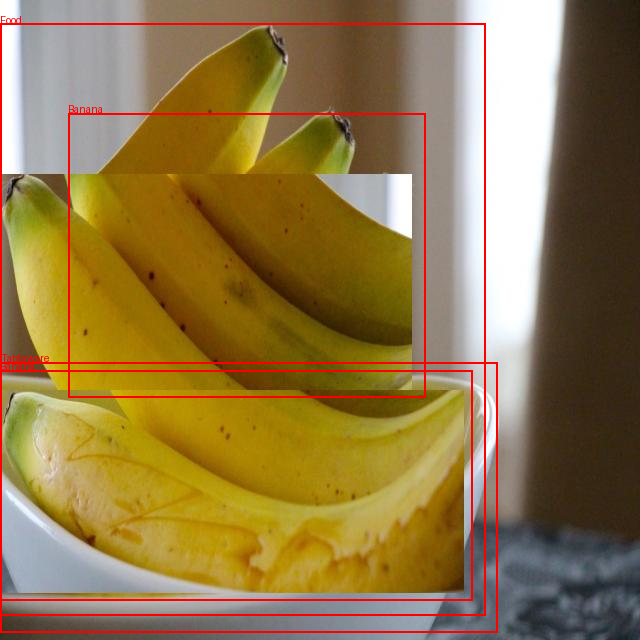

Number of objects found: 4

Banana (confidence: 0.6466578841209412)
Normalized bounding polygon vertices: 
 - (0.10693359375, 0.1767578125)
 - (0.6640625, 0.1767578125)
 - (0.6640625, 0.62109375)
 - (0.10693359375, 0.62109375)

Banana (confidence: 0.6058458685874939)
Normalized bounding polygon vertices: 
 - (0.0, 0.578125)
 - (0.73828125, 0.578125)
 - (0.73828125, 0.9375)
 - (0.0, 0.9375)

Tableware (confidence: 0.5832421779632568)
Normalized bounding polygon vertices: 
 - (0.00142669677734375, 0.56640625)
 - (0.77734375, 0.56640625)
 - (0.77734375, 0.98828125)
 - (0.00142669677734375, 0.98828125)

Food (confidence: 0.5417581796646118)
Normalized bounding polygon vertices: 
 - (0.0006103515625, 0.037353515625)
 - (0.7578125, 0.037353515625)
 - (0.7578125, 0.9609375)
 - (0.0006103515625, 0.9609375)


In [21]:
# predict objects from 1st image in training set
image_file_path = train_image_files[random.randint(0, len(train_image_files)-1)]
object_annotations = localize_objects(image_file_path)
annotate_image(image_file_path, object_annotations)
print_vertices(object_annotations)

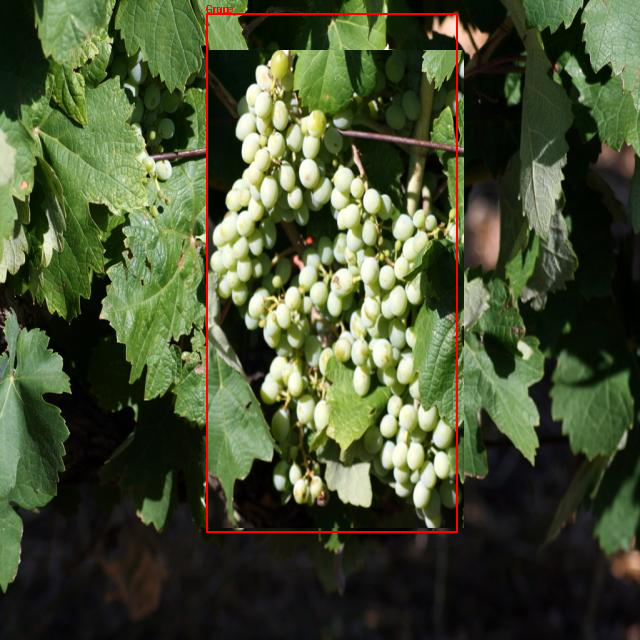

In [22]:
# predict objects from 2nd image in training set
image_file_path = train_image_files[random.randint(0, len(train_image_files)-1)]
object_annotations = localize_objects(image_file_path)
annotate_image(image_file_path, object_annotations)

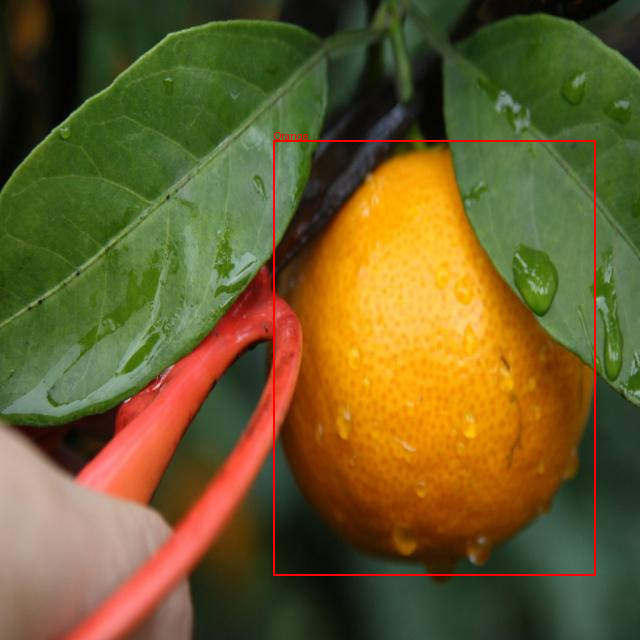

In [23]:
# predict an objects from testing set
image_file_path = test_image_files[random.randint(0, len(test_image_files)-1)]
object_annotations = localize_objects(image_file_path)
annotate_image(image_file_path, object_annotations)

### Evaluation

In [24]:
# hold scores
ious = []
map_scores = []
confidence_score = []
recall_scores = []
precision_scores = []
f1_scores = []
bbox_map_scores = []

# interate through all test files
for image, label in zip(test_image_files, test_labels_files):
    eval_results = evaluate_object_detection(image, label, yaml_file)
    for res in eval_results:
        ious.append(res['iou'])

# accumulate scores
avg_iou = sum(ious) / len(ious) if len(ious) > 0 else 0
avg_map = sum(map_scores) / len(map_scores) if len(map_scores) > 0 else 0
avg_conf = sum(confidence_score) / len(confidence_score) if len(confidence_score) > 0 else 0
avg_recall = sum(recall_scores) / len(recall_scores) if len(recall_scores) > 0 else 0  
avg_precision = sum(precision_scores) / len(precision_scores) if len(precision_scores) > 0 else 0
avg_f1 = sum(f1_scores) / len(f1_scores) if len(f1_scores) > 0 else 0
avg_bbox_map = sum(bbox_map_scores) / len(bbox_map_scores) if len(bbox_map_scores) > 0 else 0

In [25]:
# print results
print(f"Intersection over Union (IoU): {avg_iou:.4f}")
print(f"Mean Average Precision (mAP): {avg_map:.4f}")
print(f"Confidence Threshold Score: {avg_conf:.4f}")
print(f"Recall: {avg_recall:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"F1 Score : {avg_f1:.4f}")
print(f"Bounding Box Mean Average Precision: {avg_bbox_map:.4f}")

Intersection over Union (IoU): 0.5537
Mean Average Precision (mAP): 0.0000
Confidence Threshold Score: 0.0000
Recall: 0.0000
Precision: 0.0000
F1 Score : 0.0000
Bounding Box Mean Average Precision: 0.0000
